# Seismology: Earthquake frequency

**Question:** Where are earthquakes occurring most frequently in a given region?

Reference notebook for The Pond. All observations and locations are **synthetic**, created for this activity; results are not evidence about a real site.

## Preamble: From sketch to notebook

In a previous [LiLyPad](https://linked.earth/ThePond/lilypads/workflow/sketching-workflows/index.html), you sketched a workflow to identify where earthquakes occur most frequently within a region.

Here, we use an earthquake catalog to investigate that question. The catalog is considered complete for earthquakes of magnitude 2.0 or greater between 2015 and 2024. We will select events that meet these criteria, count earthquakes within 10 × 10 km grid cells, and map their distribution.

As you work through the notebook, consider how the narrative, code, and results correspond to the data, analysis steps, and parameters in your sketch.

<div class="alert alert-block alert-info">
    <b>Note:</b> Catalog completeness describes how reliably earthquakes are recorded. For this exercise, we assume that all earthquakes of magnitude 2.0 or greater within the study region were recorded during 2015–2024. Smaller earthquakes may be missing, so including them could make comparisons between locations misleading.
</div>

In this notebook, we will translate that sketch into a computational workflow. As you work through each section, notice:

- What data does the step receive?
- What operation does it perform?
- What parameters or decisions control that operation?
- What does it produce, and which step uses that output?

An output does not need to be saved as a separate file. It can be a table or another object held in memory, provided we explain what it contains and how it is used.

Follow each input → analysis → output connection in your sketch. Markdown explains meaning, documents choices, and describes manual steps; code performs computational operations; displayed tables and figures let us inspect the results.


<div class="alert alert-block alert-info">
    <b>Note:</b> A notebook’s preamble introduces the scientific questions it addresses and explains how its analyses fit into the broader study. It is also a useful place to document data sources and software dependencies, including their versions.
</div>

## Exploratory Data Analysis

Let's first load our data and understand how it is organized.

Each row is a catalog record. `event_id` identifies an earthquake, and `time` gives its date and time in UTC. `latitude` and `longitude` describe its location in degrees, while `magnitude` describes its size.

Some earthquakes appear more than once in the catalog. Records with the same `event_id` refer to the same event and should only be counted once.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

raw = pd.read_csv("data/seismology.csv")

print(f"Input: {len(raw)} records")
display(raw.head())

Input: 515 records


,event_id,time,longitude,latitude,magnitude
0,E0000,2013-01-01 00:00:00.000000000,-119.695477,35.291100,2.09
1,E0001,2013-01-10 12:18:45.450901803,-119.816487,35.323406,2.51
2,E0002,2013-01-20 00:37:30.901803607,-119.998902,35.176045,1.31
3,E0003,2013-01-29 12:56:16.352705411,-119.675510,35.207699,2.13
4,E0004,2013-02-08 01:15:01.803607214,-119.790403,35.207041,2.29


## Data Pre-Processing

Our first step is to remove duplicate records so that each earthquake is counted only once. We use `event_id` to identify repeated events and retain the first record for each identifier.

<div class="alert alert-block alert-info">
    <b>Note:</b> In this synthetic catalog, records with the same event identifier contain identical information. If they differed—for example, because an earthquake’s location or magnitude had been revised—we would need to decide which record to retain and document that choice.
</div>

In [2]:
unique = raw.drop_duplicates(subset="event_id").copy()
unique["time"] = pd.to_datetime(unique["time"], utc=True)

print(f"{len(raw)} catalog records → {len(unique)} unique earthquakes")
display(unique.head())

515 catalog records → 500 unique earthquakes


,event_id,time,longitude,latitude,magnitude
0,E0000,2013-01-01 00:00:00+00:00,-119.695477,35.291100,2.09
1,E0001,2013-01-10 12:18:45.450901803+00:00,-119.816487,35.323406,2.51
2,E0002,2013-01-20 00:37:30.901803607+00:00,-119.998902,35.176045,1.31
3,E0003,2013-01-29 12:56:16.352705411+00:00,-119.675510,35.207699,2.13
4,E0004,2013-02-08 01:15:01.803607214+00:00,-119.790403,35.207041,2.29


To map earthquake locations, we need both latitude and longitude. We therefore remove records missing either coordinate. The resulting catalog contains one record per earthquake with a recorded location.

In [3]:
located = unique.dropna(subset=["latitude", "longitude"]).copy()

print(f"{len(unique)} earthquakes → {len(located)} with both coordinates")
display(located.head())

500 earthquakes → 494 with both coordinates


,event_id,time,longitude,latitude,magnitude
0,E0000,2013-01-01 00:00:00+00:00,-119.695477,35.291100,2.09
1,E0001,2013-01-10 12:18:45.450901803+00:00,-119.816487,35.323406,2.51
2,E0002,2013-01-20 00:37:30.901803607+00:00,-119.998902,35.176045,1.31
3,E0003,2013-01-29 12:56:16.352705411+00:00,-119.675510,35.207699,2.13
4,E0004,2013-02-08 01:15:01.803607214+00:00,-119.790403,35.207041,2.29


We next restrict the catalog to earthquakes recorded between 2015 and 2024, the period for which catalog completeness is specified. We include events from January 1, 2015, up to—but not including—January 1, 2025. This retains the entire final day of 2024, regardless of the event’s time.


In [5]:
START = '2015-01-01'
STOP = '2025-01-01'
dated = located.loc[located.time.ge(START) & located.time.lt(STOP)].copy()
print(f'{len(located)} → {len(dated)} events')

494 → 384 events


We now retain earthquakes with a magnitude of 2.0 or greater, the threshold above which the catalog is considered complete during our study period. Events with a magnitude exactly equal to 2.0 are included.

The resulting catalog contains one record per earthquake, with both coordinates available, recorded during 2015–2024, and meeting our magnitude threshold.


In [6]:
MIN_MAGNITUDE = 2.0

selected = dated.loc[
    dated["magnitude"].ge(MIN_MAGNITUDE)
].copy()

print(f"{len(dated)} earthquakes → {len(selected)} with magnitude ≥ {MIN_MAGNITUDE}")
display(selected.head())

384 earthquakes → 253 with magnitude ≥ 2.0


,event_id,time,longitude,latitude,magnitude
80,E0080,2015-02-01 01:00:36.072144288+00:00,-119.917396,35.323906,3.84
81,E0081,2015-02-10 13:19:21.523046096+00:00,-119.686111,35.255461,2.34
83,E0083,2015-03-01 13:56:52.424849704+00:00,-119.768415,35.302339,3.58
84,E0084,2015-03-11 02:15:37.875751504+00:00,-119.757768,35.370204,2.25
86,E0086,2015-03-30 02:53:08.777555112+00:00,-119.710110,35.337435,3.14


## Analysis

To compare earthquake counts across the region, we will divide it into 10 × 10 km grid cells. Our coordinates are currently in degrees of latitude and longitude, so we first express each earthquake’s location as a distance east and north of a reference point at 35°N, 120°W.

The resulting table retains the earthquake information and adds two columns: `east_km` and `north_km`.

<div class="alert alert-block alert-info">
    <b>Note:</b> For this synthetic example, we use an approximate conversion from degrees to kilometers, accounting for longitude spacing at the reference latitude. Our grid cells are therefore approximately 10 × 10 km. For a real regional study, we would use a suitable projected coordinate system and document that choice.
</div>

In [7]:
LAT0 = 35.0
LON0 = -120.0
KM_PER_DEGREE = 111.195

spatial = selected.copy()

spatial["east_km"] = (
    (spatial["longitude"] - LON0)
    * KM_PER_DEGREE
    * np.cos(np.deg2rad(LAT0))
)

spatial["north_km"] = (
    (spatial["latitude"] - LAT0)
    * KM_PER_DEGREE
)

display(
    spatial[["event_id", "latitude", "longitude", "east_km", "north_km"]].head()
)

,event_id,latitude,longitude,east_km,north_km
80,E0080,35.323906,-119.917396,7.523999,36.016708
81,E0081,35.255461,-119.686111,28.590749,28.405954
83,E0083,35.302339,-119.768415,21.094104,33.618577
84,E0084,35.370204,-119.757768,22.063879,41.164826
86,E0086,35.337435,-119.710110,26.404771,37.521051


We divide our study region into cells approximately 10 km wide in both directions. The grid extends from 0 to 60 km east and north of our reference point, forming 36 cells.

We then count the earthquakes within each cell over the full 2015–2024 period. The result is a two-dimensional array, `counts`, containing one earthquake count per cell, including zeros where no events were recorded.

<div class="alert alert-block alert-info">
    <b>Note:</b> Cell size, grid origin, and spatial extent are all choices that should be documented. Changing the boundaries can change which earthquakes are grouped together. Events on a boundary are assigned to the cell beginning at that boundary, except along the outermost edge, which is included in the final cell.
</div>

In [8]:
CELL_KM = 10
EXTENT_KM = 60

x_edges = np.arange(0, EXTENT_KM + CELL_KM, CELL_KM)
y_edges = np.arange(0, EXTENT_KM + CELL_KM, CELL_KM)

# Check that all selected earthquakes fall within our study region.
assert spatial["east_km"].between(0, EXTENT_KM).all()
assert spatial["north_km"].between(0, EXTENT_KM).all()

counts, x_edges, y_edges = np.histogram2d(
    spatial["east_km"],
    spatial["north_km"],
    bins=[x_edges, y_edges]
)

counts = counts.astype(int)

# Each earthquake should be counted exactly once.
assert counts.sum() == len(spatial)

print(f"Grid: {counts.shape[0]} × {counts.shape[1]} cells")
print(f"Total earthquakes counted: {counts.sum()}")
print(f"Highest count in a single cell: {counts.max()}")

Grid: 6 × 6 cells
Total earthquakes counted: 253
Highest count in a single cell: 30


## Visualization

Let's map the number of earthquakes recorded in each grid cell. The color shows the total count during 2015–2024, with brighter colors indicating more events. The axes show distances east and north of our reference point.

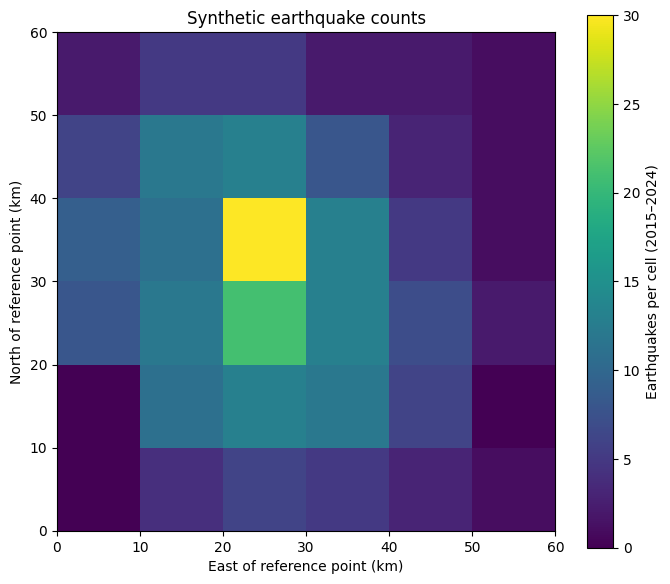

In [10]:
fig, ax = plt.subplots(figsize=(7, 6))

image = ax.pcolormesh(
    x_edges,
    y_edges,
    counts.T,
    cmap="viridis",
    shading="flat"
)

fig.colorbar(
    image,
    ax=ax,
    label="Earthquakes per cell (2015–2024)"
)

ax.set(
    xlabel="East of reference point (km)",
    ylabel="North of reference point (km)",
    title="Synthetic earthquake counts",
    aspect="equal"
)

fig.tight_layout()

The highest-count cells identify where earthquakes occurred most frequently in this synthetic catalog during our study period. This pattern depends on our magnitude threshold, time interval, and grid boundaries.

The map shows earthquake counts, not earthquake hazard. It does not account for differences in earthquake magnitude above our threshold or estimate the likelihood of future damaging events.

If you need help, look at the workflow sketch below: 

<details>
<summary><strong>Show the reference workflow</strong></summary>

![Reference workflow for the seismology scenario](./figures/seismology-workflow-answer.png)

</details>